## 文本预处理: 读取数据集 + 词元化（分词） + 词表
这里采用了直接从本地目录下读取数据集文件，注意kaggle和本地Pycharm分情况讨论，防止移动到kaggle上运行时读取不到数据集报错


In [16]:
import collections
import re

#1.读取数据集
import hashlib  #提供了常见的哈希算法（也叫散列算法、摘要算法）。它可以把任意长度的数据（比如字符串、文件内容）转换成一个固定长度的、不可逆的“指纹”（哈希值）。
import os
import tarfile      #处理 .tar、.tar.gz、.tar.bz2 等格式
import zipfile      #处理 .zip 格式
import requests     #requests 是用来发送 HTTP 请求的库
def get_data_path():
    # 在 Kaggle 上的路径
    kaggle_path = '/kaggle/input/datasets/a1538879450/time-machine/time_machine.txt'
    # 在本地调试的路径（根据你本地存放的位置修改）
    local_path = '../data/time_machine.txt'
    
    if os.path.exists(kaggle_path):
        return kaggle_path
    elif os.path.exists(local_path):
        return local_path
    else:
        raise FileNotFoundError("找不到数据文件，请检查路径！")
def read_time_machine():
    #下载时间机器数据集，转化为 多个文本行组成的列表
    with open(get_data_path(), 'r') as f:
        lines = f.readlines()
        return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]#忽略标点符号和字母大写

#2.词元化（分词）
def tokenize(lines, token='word'):
    #输入文本和分词方式，输出分词后的文本 [文本行数，token数]，即第0维表示第几行，第1维表示该行第几个token
    if token == 'word':
        return [line.split() for line in lines]    #line.spilit()将字符串拆分成列表
    elif token == 'char':
        return [list(line) for line in lines]
#3.词表
class Vocab:  #@save
    """文本词表"""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        #tokens是从文本提取出的词元，reserved_tokens是预留词元，是人为定义的一部分词元，如<pad>,<bos>, <eos>等
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # 按出现频率排序
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True)    #sorted(iterable, key=None, reverse=False)
                                                    #sorted返回的类型始终为list，这里类似[('the', 100), ('time', 50), ('machine', 30)]
        # 未知词元的索引为0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}   #字典推导式
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):#重定义后可直接[]，通过token得到idx
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # 未知词元的索引为0
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs

def count_corpus(tokens):  #@save
    """统计词元的频率"""
    # 这里的tokens是1D列表或2D列表
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # 将词元列表展平成一个列表（因为二维列表的话，第二维就是一个列表，不可哈希，不能传入Counter()）
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)  #coleections.Counter用于统计可哈希对象的出现次数。

def load_corpus_time_machine(max_tokens= -1):
    lines = read_time_machine() #下载读取数据集
    tokens = tokenize(lines, 'char')    #分词， lines:[行数，] -> tokens[行数，每行token数]
    vocab = Vocab(tokens)   #得到词表
    corpus = [vocab[token] for line in tokens for token in line]    #tokens转成用数字索引表示的一维长文本
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab


## 文本预处理：构建数据集迭代器dataloader

In [17]:
import random
import torch

#以下两个函数是将长文本列表corpus分成多个小批量
def seq_data_iter_random(corpus, batch_size, num_steps):
    """
    随机抽样
    给定长文本序列corpus，批量大小batch_size，子序列长度（时间步)/也叫特征数 num_steps,
    将corpus拆分成多个子序列，作为多个样本，并打乱顺序，分批放入多个批次中。
    return:数据集迭代器.按照批次遍历，每个元素是[batch_size, num_steps]
    """
    corpus = corpus[random.randint(0, num_steps - 1) :] #从随机偏移量开始进行分区
    num_subseqs = (len(corpus) - 1) // num_steps    #子序列数。-1是因为要考虑标签
    #拆分成多个子序列,子序列用每个子序列在corpus中的初始位置索引表示
    initial_indices = list(range(0, num_steps * num_subseqs, num_steps))
    random.shuffle(initial_indices) #因为是随机抽样，所以将子序列对应的索引打乱，相当于打乱子序列
    
    def data(pos): #访问子序列直接用索引，这里是根据子序列在corpus中的初始索引快速得到子序列
        return corpus[pos : pos + num_steps]
    
    num_batches = num_subseqs // batch_size #批次数=总子序列数（样本数） // 批量大小
    for i in range(0, batch_size * num_batches, batch_size): #corpus中所有子序列分批，分批遍历
            # 如果把所有子序列从前往后编号，则i表示每一批的子序列初始编号.
        initial_indices_per_batch = initial_indices[i : i + batch_size]#这一批每个子序列的初始索引
        x = [data(j) for j in initial_indices_per_batch]
        y = [data(j+1) for j in initial_indices_per_batch]
        yield torch.tensor(x), torch.tensor(y)        

def seq_data_iter_sequential(corpus, batch_size, num_steps):
    """
    顺序分区，要求相邻批次的相同编号的子序列在原文本也相邻。即批次0的子序列1与批次1的子序列1相邻；批次0的子序列0与批次1的子序列0相邻
    思路：由于最后输出一个迭代器，迭代器的每个元素是一个批次的子序列[batch_size, num_steps]。
    可以先将长文本序列[len(corpus)] =>[batch_size, -1]。然后此时列维度再按num_steps分割的同时返回值
    这样每分隔一次得到一个[batch_size, -1]，作为一个批次，而且满足顺序分区要求，可以画图想想想"""
    corpus = corpus[random.randint(0, num_steps - 1) :] #从随机偏移量开始分割序列
    num_tokens = ((len(corpus) - 1) // batch_size) * batch_size #保证能按batch_size拆分成多行
    xs = torch.tensor(corpus[:num_tokens])
    ys = torch.tensor(corpus[1: num_tokens + 1])
    xs , ys = xs.reshape(batch_size, -1), ys.reshape(batch_size, -1)
    #现在是[batch_size, num_tokens / batch_size]。再按列拆分成多个批次，使得每个批次是[batch_size, num_steps]
    num_batches = xs.shape[1] // num_steps  #上面得到的列数只保证了能被batch_size整除，这里还要保证能被num_steps整除
    for i in range(0, num_batches * num_steps, num_steps):
        #i是每个子序列的初始列索引，num_batches*num_steps是总列数，保证了能被num_steps整除,即能够按照子序列长度分割
        x = xs[:, i : i + num_steps]
        y = ys[:, i : i + num_steps]
        yield x, y

#将以上两个不同的将长文本序列转换为多个小批量子序列的函数包装到一个类中，
#用作数据迭代器
class SeqDataLoader:
    def __init__(self, batch_size, num_steps, use_random_iter, max_tokens):
        if use_random_iter:
            self.data_iter_fn = seq_data_iter_random
        else:
            self.data_iter_fn = seq_data_iter_sequential
        self.corpus, self.vocab = load_corpus_time_machine(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps
    
    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)
    
    def __len__(self):
        # 计算能产生多少个批次
        # 先计算可用的 token 数量（保证能被 batch_size 整除）
        num_tokens = ((len(self.corpus) - 1) // self.batch_size) * self.batch_size
        # 再计算列数，最后除以 num_steps 得到批次数
        num_batches = (num_tokens // self.batch_size) // self.num_steps
        return num_batches

def load_data_time_machine(batch_size, num_steps, use_random_iter=False, max_tokens=10000):
    #返回数据集迭代器和词表
    data_iter = SeqDataLoader(batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab



## 文本预处理：利用上述定义函数得到数据迭代器和词表
数据迭代器train_iter:[batch_size, num_steps]

In [18]:
batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

## 定义模型

In [13]:
import torch
from torch import nn
from torch.nn import functional as F

"""
定义具有256个隐藏单元的单隐藏层的循环神经网络层RNN
单隐藏层解释：
    输入层 → 隐藏层 → 输出层
             ↑   ↓
             循环连接（记忆）
    数学表示：设第t个时间步隐藏状态h_t,输入x_t,输出o_t
            h_t = tanh(W_xh · x_t + W_hh · h_{t-1} + b_h)
            o_t = W_ho · h_t + b_o
"""


#测试state和rnn_layer
# rnn_layer = nn.RNN(len(vocab), num_hiddens) #输入特征维度->隐藏状态维度。即[时间步，batch_size,vocab_size] -> [时间步,batch_size, num_hiddens]
#初始化所有隐藏层的隐藏状态，[隐藏层数，batch_size, num_hiddens].为什么没有时间步维度？因为每个时间步都用state，新state将旧state覆盖
# state = torch.zeros(1, batch_size, num_hiddens)
# x = torch.rand(size=(num_steps, batch_size, len(vocab)))#时间步大小就是子序列(样本)token数，即子序列大小
# y, state_new = rnn_layer(x, state)
# y.shape, state_new.shape

#定义完整循环神经网络模型
class RNNModel(nn.Module):
    def __init__(self, rnn_layer, vocab_size, num_hiddens, **kwargs):    #rnn隐藏层数，词表大小
        super(RNNModel, self).__init__(**kwargs)
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.rnn = nn.RNN(vocab_size, num_hiddens) # rnn隐藏层，输入特征维度->隐藏状态维度。即[时间步(序列token长度)，batch_size,vocab_size] -> [时间步,batch_size, num_hiddens]
        
        #RNN是单向还是双向分情况
        if not self.rnn.bidirectional:
            self.num_directions = 1
            self.linear = nn.Linear(self.num_hiddens, self.vocab_size)  #输出层
        else:
            self.num_directions = 2
            self.linear = nn.Linear(self.num_hiddens * 2, self.vocab_size)
    def forward(self, inputs, state):    #不能光传个输入x，还得传初始隐藏状态state
        #inputs: [batch_size, num_steps] ->  x:[num_steps, batch_size, vocab_size]
        x = F.one_hot(inputs.T.long(), self.vocab_size)
        x = x.to(torch.float32)
        y, state = self.rnn(x, state)
            #输出[num_steps*batch_size, vocab_size],故先将y改为[num_steps*batch_size, num_hiddens].再经过输出层。由于可能是双向RNN，最后一维可能是num_hiddens也可能是2*num_hiddens,故用y.shape[-1]表示最后一维大小
        #num_steps*batch_size的原因是为了适配损失函数，因为交叉熵损失函数要求输入[N,C],N是样本数，C是类别数
        output = self.linear(y.reshape(-1, y.shape[-1]))  
        return output, state
    
    def begin_state(self, device, batch_size=1):    #初始化隐藏状态
        if not isinstance(self.rnn, nn.LSTM):   #若self.rnn是nn.LSTM类型
            # nn.GRU以张量作为隐状态 h
            return  torch.zeros((self.num_directions * self.rnn.num_layers,
                                 batch_size, self.num_hiddens),
                                device=device)
        else:
            # nn.LSTM以元组作为隐状态 (h, c)
            return (torch.zeros((
                self.num_directions * self.rnn.num_layers,
                batch_size, self.num_hiddens), device=device),
                    torch.zeros((
                        self.num_directions * self.rnn.num_layers,
                        batch_size, self.num_hiddens), device=device))

## 训练前预先定义工具函数：计时器Timer类，多变量累加Accumulator类,绘制图表Animator类

In [7]:
import time
import numpy as np
class Timer: 
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间。即列表转换为前缀和列表.利用了numpy数组的cumsum()函数"""
        return np.array(self.times).cumsum().tolist()

class Accumulator:  
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n   #data存n个变量

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)] #data和args都是列表，data和args每个元素对应相加

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

#梯度裁剪
def grad_clipping(net, theta):  #@save
    """裁剪梯度"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

#%matplotlib inline 是 Jupyter Notebook 中的魔法命令（magic command），用于将 matplotlib 绘制的图表直接嵌入在 Notebook 单元格的输出中。
#魔法命令是 IPython（Jupyter Notebook 的内核）提供的特殊命令，用于执行一些普通 Python 语法无法直接完成的操作。它们以 % 或 %% 开头。
%matplotlib inline       
import numpy as np
from matplotlib_inline import backend_inline    #负责内嵌图表的渲染
from matplotlib import pyplot as plt   
def use_svg_display():  #@save
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('png')    #pycharm里用svg显示不了，故用png
    
def set_figsize(figsize=(3.5, 2.5)):  #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    #设置 matplotlib 全局的图形默认大小。rc是Runtime Configuration（运行时配置），params是参数。rcParams是matplotlib的全局配置字典，可以修改图表的默认行为
    plt.rcParams['figure.figsize'] = figsize    #宽3.5英寸，高2.5英寸

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel) #y轴标签，如'loss'
    axes.set_xscale(xscale) #X轴刻度类型，如'linear'(线性) 或 'log'(对数)
    axes.set_yscale(yscale) #Y轴刻度类型
    axes.set_xlim(xlim) #X轴显示范围，如(0, 10)
    axes.set_ylim(ylim) #Y轴显示范围
    if legend:
        axes.legend(legend) #legend：图例标签列表，如['train', 'test']
    axes.grid()    # 显示网格线（默认）.axes.grid(False)是隐藏网格线
    
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """绘制数据点"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else plt.gca()

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
    
    
from IPython import display
class Animator:  #pycharm里用此类没法动态刷新，但在kaggle中能正常用
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        #y的长度就是不同曲线的个数，x要保证和y的长度一致(x可能传的是一个数)
        #self.X的长度也是不同曲线的个数。self.X的每个元素是一个列表，，self.X[0]是第0个曲线的所有点的x轴坐标
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()    #清楚当前子图内容（只针对axes[0]这单个子图）
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

## 训练和预测：函数定义

In [19]:
import math

def predict(prefix, num_preds, net, vocab, device): 
    """
    输入已有字符串，预测token数，模型，词表
    输出预测后包括之前已有字符的完整字符串
    """
    #prefix:str类型字符串，据此预测; num_preds:预测的token数
    state = net.begin_state(batch_size= 1, device=device)   #预测时batch_size=1,不用分批多段
    outputs = [vocab[prefix[0]]]
    get_input = lambda:torch.tensor([outputs[-1]], device=device).reshape((1, 1))   #一个元素的一维张量->(1,1)二维张量.  根据前一个字符输入和该时间步隐状态，来得到输出和下一时间步隐状态，故此处定义一个函数
    for y in prefix[1:]:    #预热期    为什么从1开始？因为prefix[0]对应索引已经在outputs中
                        #注意每一步遍历，outputs比state多一个字符，即state看到的是outputs除最后一个字符外的字符形成的隐状态
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)  #y:(N,C),这里是(1,vocab_size)
        outputs.append(int(y.argmax(dim=1).reshape(1))) #相当于多分类问题，取最大概率对应的token索引
    return ''.join([vocab.idx_to_token[i] for i in outputs])    #''作为分隔符，相当于直接连接
    
    
def train_epoch(net, train_iter, loss, updater, device, use_random_iter):
    #训练一轮, use_random_iter表示选择随机抽样还是顺序分区进行分批
    state, timer = None, Timer()
    metric = Accumulator(2) #训练损失之和， 词元数量
    for x, y in train_iter: #每个小批量遍历
        # x:[batch_size, num_steps],记得模型的输入也是这个.在模型里才转化为[num_steps,batch_size,vocab_size]
        # 对于最普通的RNN， state:[num_steps, batch_size, num_hiddens],由batch_size维可知对于每个小批量，每个样本的隐状态是独立的，只不过计算的时候按照num_steps维h_0,h_1...串行计算，同时利用矩阵乘法使得所有样本的h_t并行计算
        if state is None or use_random_iter:
            #初始化隐状态
            state = net.begin_state(device = device, batch_size = x.shape[0])
        else:
            #分离梯度
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                #是GRU
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        y = y.T.reshape(-1) #y: [batch_size,num_steps] -> [num_steps*batch_size, ]
                            #因为损失函数要求预测值[N,C],真实值[N,]
        x, y = x.to(device), y.to(device)
        
        y_hat, state = net(x, state)
        l = loss(y_hat, y.long()).mean()
        
        updater.zero_grad()
        l.backward()
        grad_clipping(net, 1)   #梯度裁剪
        updater.step()
        
        metric.add(l*y.numel(), y.numel()) #y.numel()是num_steps*batch_size,即此小批量中的词元数量，而l是所有词元的平均损失，故*y.numel()得到总损失
        return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()    #困惑度是e^交叉熵损失;      平均每个词元所用时间
        
def train(net, train_iter, vocab, lr, num_epochs, device, use_random_iter = False):
    assert len(train_iter) > 0, "训练数据为空！请检查数据路径。"
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel = 'epoch', ylabel = 'perplexity', legend = ['train'], xlim = [10, num_epochs])   #跳过前10轮的绘图
    updater = torch.optim.SGD(net.parameters(), lr)
    predict_50 = lambda prefix:predict(prefix, 50, net, vocab, device)#预测50个token。因为是函数所以lambda关键字创建匿名函数.注意等号左边和右边的函数名不能相同，否则会无限递归调用
    for epoch in range(num_epochs):
        ppl, speed = train_epoch(net, train_iter, loss, updater, device, use_random_iter)   #困惑度：e^平均交叉熵损失, 速度：token数/训练一轮消耗时间
        if(epoch+1) % 10 == 0: #每十轮进行一次预测和 图像增加点,输出预测结果看一下
            print(predict_50('time traveller'))
            animator.add(epoch+1, [ppl])    #图像中添加一个点，输入横纵坐标
    
    print(f'困惑度{ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    #训练完最终预测
    print(predict_50('time traveller'))
    print(predict_50('traveller'))
    

## 训练与预测：超参设置，函数调用

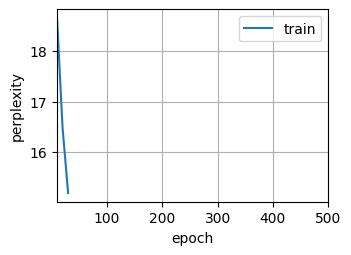

In [15]:
def try_gpu(i=0):  #@save
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')
device = try_gpu()
num_hiddens, num_epochs, lr = 256, 500, 1
net = RNNModel(nn.RNN(len(vocab), num_hiddens), vocab_size=len(vocab), num_hiddens=num_hiddens)
net.to(device)
train(net, train_iter, vocab, lr, num_epochs, device)
